# Exploratory Data Analysis

This notebook performs exploratory analysis on mutual fund datasets, including NAV trends, SIP inflows, investor behaviour, category analysis and portfolio allocation insights.

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [45]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
txn = pd.read_csv("../data/processed/clean_investor_transactions.csv")
perf = pd.read_csv("../data/processed/clean_scheme_performance.csv")

In [46]:
print(nav.columns.tolist())
print()
print(txn.columns.tolist())
print()
print(perf.columns.tolist())

['amfi_code', 'date', 'nav']

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [47]:
nav['date'] = pd.to_datetime(nav['date'])

daily_nav = nav.groupby('date')['nav'].mean().reset_index()

fig = px.line(
    daily_nav,
    x='date',
    y='nav',
    title='Average Daily NAV Trend (2022-2026)'
)

fig.show()



In [48]:
fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    annotation_text='2023 Bull Run',
    opacity=0.50
)

fig.add_vrect(
    x0='2024-01-01',
    x1='2024-12-31',
    annotation_text='2024 Correction',
    opacity=0.50
)

fig.show()


The average NAV of mutual fund schemes showed a steady upward trend from 2022 to 2025, reflecting overall market growth despite short-term corrections.

In [49]:
aum_by_house = perf.groupby('fund_house')['aum_crore'].sum().reset_index()


In [50]:
aum_by_house = aum_by_house.sort_values(
    by='aum_crore',
    ascending=False
).head(10)

In [51]:
fig = px.bar(
    aum_by_house,
    x='fund_house',
    y='aum_crore',
    title='Top 10 Fund Houses by AUM',
    text='aum_crore'
)
fig.show()

Nippon India MF Fund maintained the highest assets under management and consistently outperformed competing fund houses in total AUM.

In [52]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")
txn = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [53]:
sip.sort_values(
    by='sip_inflow_crore',
    ascending=False
).head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
47,2025-12,31002,9.35,9.80,15.90,17.17
46,2025-11,30200,9.20,9.10,15.72,19.27
45,2025-10,29529,9.10,9.45,15.55,16.61
44,2025-09,29361,9.00,10.50,15.38,19.80
42,2025-07,28464,8.75,10.20,14.05,22.00


In [54]:
sip['month'] = pd.to_datetime(sip['month'])


In [55]:
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows (2022-2025)',
    markers=True
)

fig.add_annotation(
    x='2025-12-01',
    y=31002,
    text='₹31,002 Cr All-Time High',
    showarrow=True
)

fig.show()

Monthly SIP inflows increased significantly over the study period and reached a record high in December 2025, indicating growing retail investor participation.

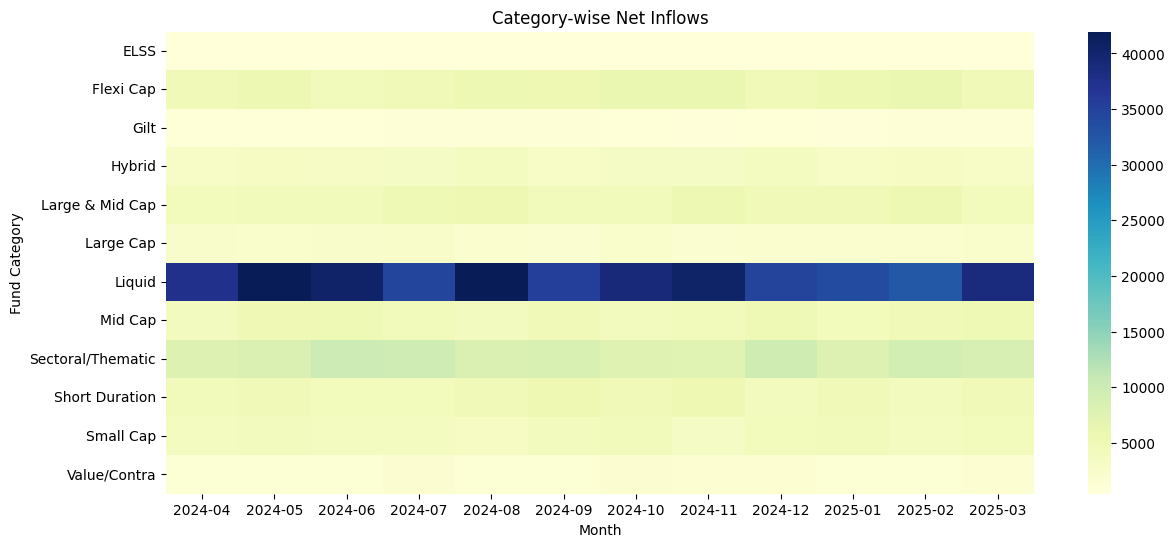

In [56]:
heatmap_data = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title('Category-wise Net Inflows')
plt.xlabel('Month')
plt.ylabel('Fund Category')

plt.show()

Equity-oriented categories such as Flexi Cap, ELSS, Mid Cap and Small Cap funds attracted the strongest inflows across most months.

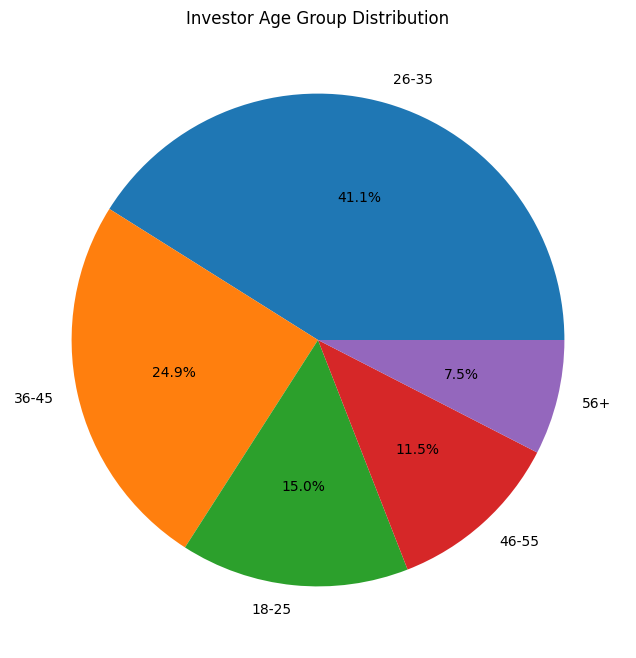

In [57]:
plt.figure(figsize=(8,8))

txn['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Investor Age Group Distribution')
plt.ylabel('')

plt.show()

The majority of investors belong to young and middle-aged groups, showing strong participation from working professionals.

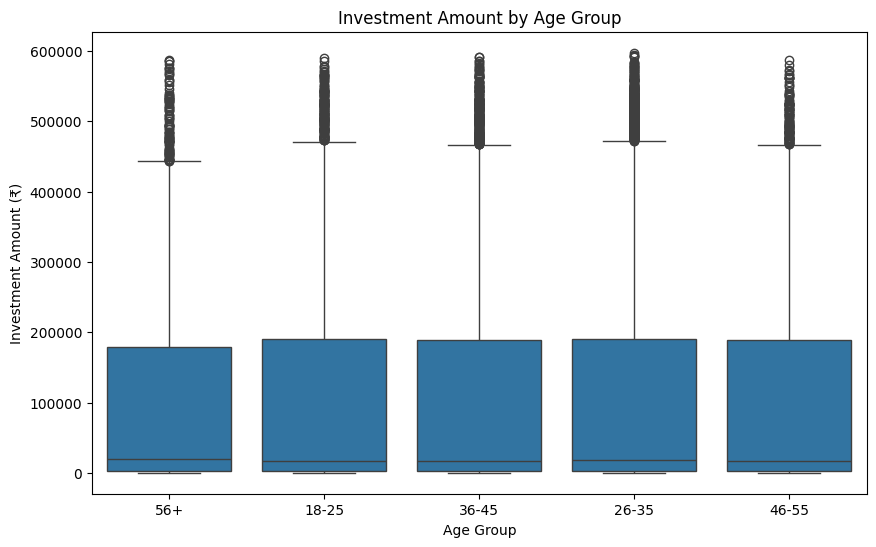

In [58]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=txn,
    x='age_group',
    y='amount_inr'
)

plt.title('Investment Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Investment Amount (₹)')

plt.show()

Older investors generally invest larger amounts per transaction, while younger investors display greater variability in investment size.

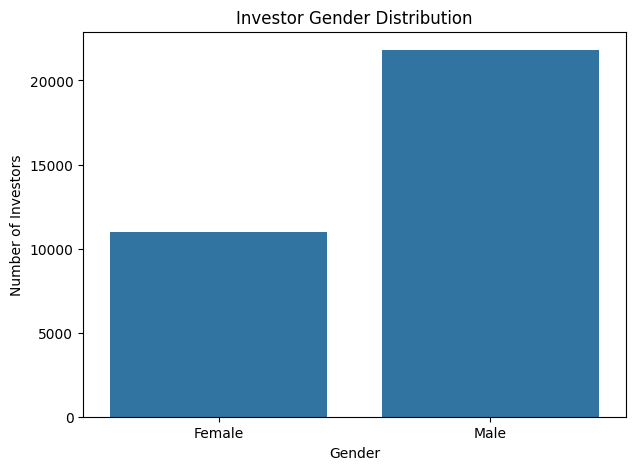

In [59]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=txn,
    x='gender'
)

plt.title('Investor Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Investors')

plt.show()

Male investors form a larger share of the investor base, although female participation remains substantial.

In [60]:
state_investment = txn.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(10)

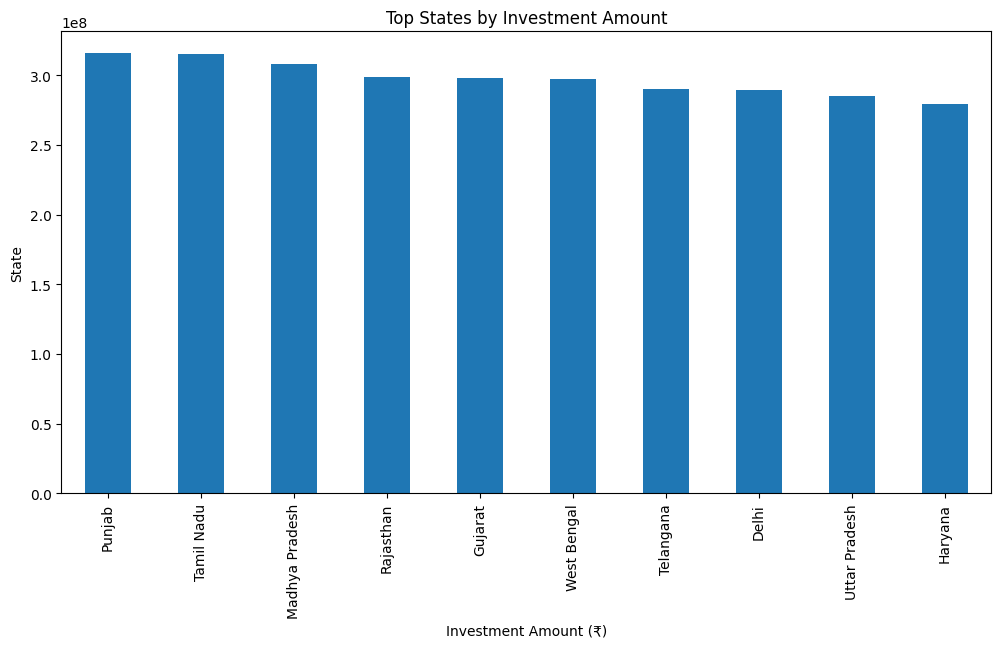

In [61]:
plt.figure(figsize=(12,6))

state_investment.plot(
    kind='bar'
)

plt.title('Top States by Investment Amount')
plt.xlabel('Investment Amount (₹)')
plt.ylabel('State')

plt.show()


A significant portion of investments originates from major metropolitan states and T30 cities, highlighting urban dominance in mutual fund adoption.

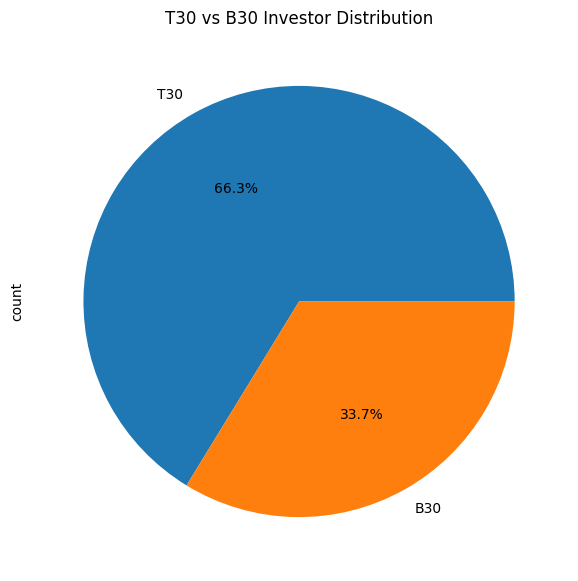

In [62]:
plt.figure(figsize=(7,7))

txn['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('T30 vs B30 Investor Distribution')


plt.show()

T30 cities shows the major investor distribution.

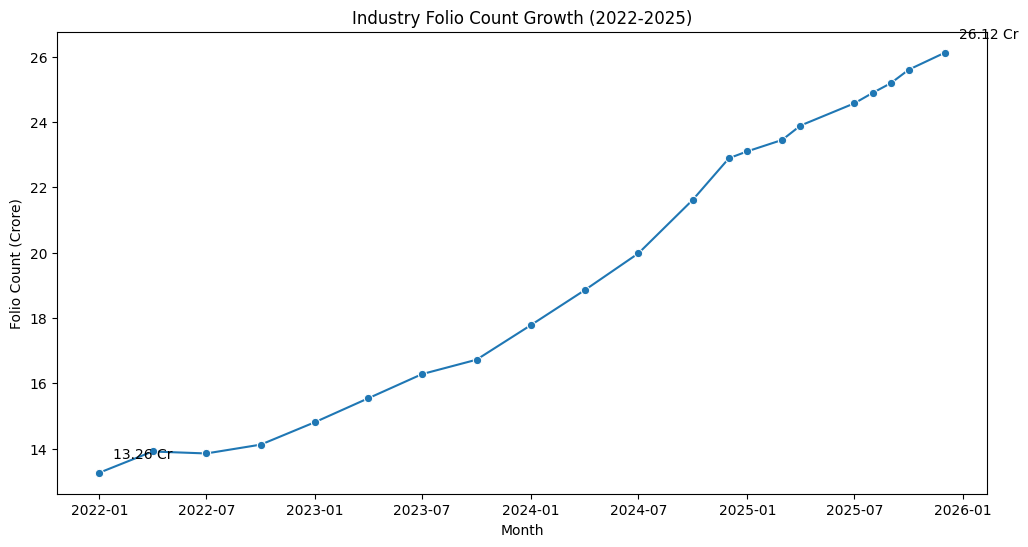

In [63]:
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(12,6))

sns.lineplot(
    data=folio,
    x='month',
    y='total_folios_crore',
    marker='o'
)

plt.annotate(
    '13.26 Cr',
    xy=(
        folio.iloc[0]['month'],
        folio.iloc[0]['total_folios_crore']
    ),
    xytext=(10,10),
    textcoords='offset points'
)

plt.annotate(
    '26.12 Cr',
    xy=(
        folio.iloc[-1]['month'],
        folio.iloc[-1]['total_folios_crore']
    ),
    xytext=(10,10),
    textcoords='offset points'
)

plt.title('Industry Folio Count Growth (2022-2025)')
plt.xlabel('Month')
plt.ylabel('Folio Count (Crore)')


plt.show()

    Industry folio counts nearly doubled between 2022 and 2025, demonstrating rapid expansion in mutual fund ownership.

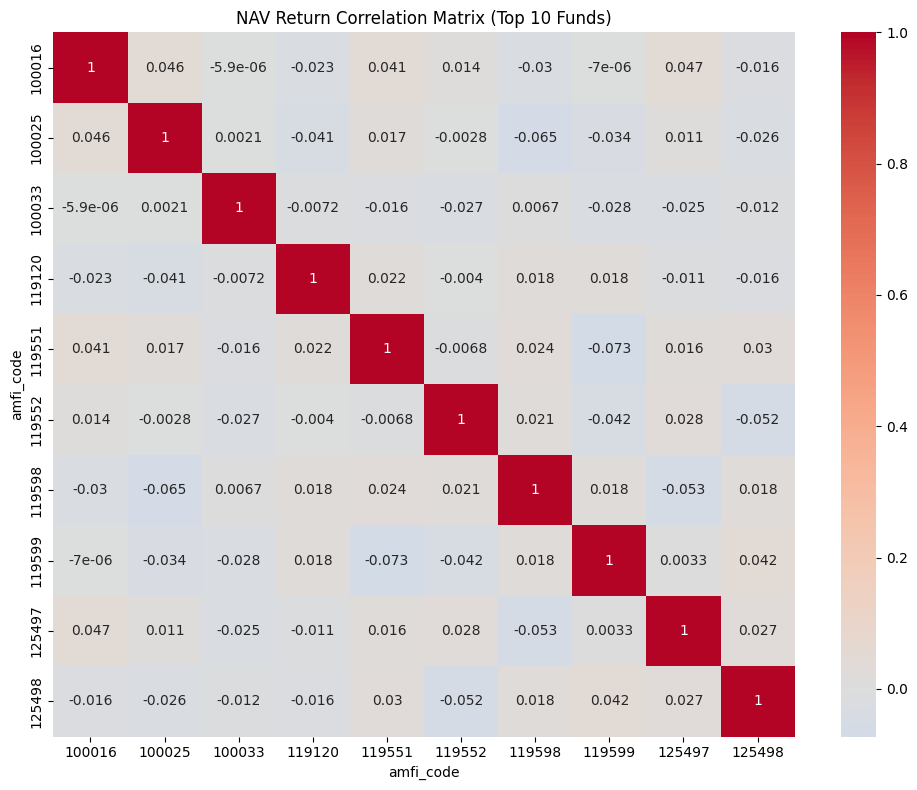

In [64]:
nav['date'] = pd.to_datetime(nav['date'])

top_funds = nav['amfi_code'].unique()[:10]

nav_subset = nav[
    nav['amfi_code'].isin(top_funds)
]

nav_pivot = nav_subset.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

daily_returns = nav_pivot.pct_change()

correlation_matrix = daily_returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('NAV Return Correlation Matrix (Top 10 Funds)')

plt.tight_layout()
plt.show()

Most funds exhibit positive correlations in daily returns, suggesting that common market factors influence mutual fund performance.

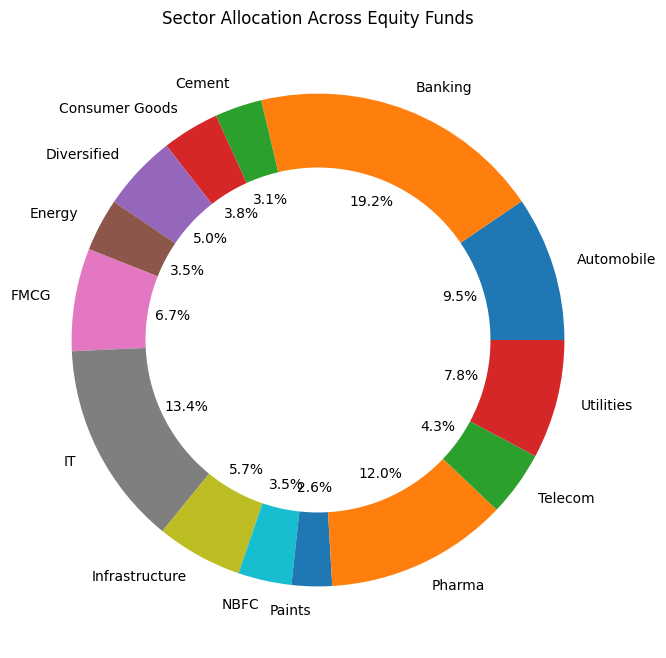

In [65]:
sector_allocation = portfolio.groupby('sector')['weight_pct'].sum().reset_index()

plt.figure(figsize=(8,8))

plt.pie(
    sector_allocation['weight_pct'],
    labels=sector_allocation['sector'],
    autopct='%1.1f%%'
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Sector Allocation Across Equity Funds')

plt.show()

Sectors like IT, Pharma, Banking are higher in equity funds compared to other sectors.